# Summarize the Results

In [1]:
import os
import re
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import pandas as pandas
import matplotlib.pyplot as plt

/home/stud/kgutjahr/miniconda3/envs/stil/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_PATH = "/data/local/kgutjahr/results/test/runs/eval/ADNI"

In [3]:
def plot_grouped_heatmap(path: str):
    df = pd.read_csv(path).iloc[:, :-1]
    df = df.fillna(0)

    # Create combined Shift + Method column
    df['Shift_Method'] = df['Shift'] + " x " + df['Method']
    # Automatically select numeric columns
    
    numeric_cols = df.select_dtypes(include=['number']).columns

    # Set index for heatmap
    heatmap_df = df.set_index('Shift_Method')[numeric_cols]

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(heatmap_df, cmap="RdBu", annot=True, fmt=".1f", vmin=0, vmax=100)

    # Rotate labels
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    # Add thick horizontal lines between Shifts
    shift_groups = df.groupby('Shift').size().cumsum()  # positions where each shift ends
    for pos in shift_groups[:-1]:  # skip the last line
        ax.hlines(pos, *ax.get_xlim(), colors='black', linewidth=3)

    plt.title("Heatmap of Accuracy (in %)", pad=20)
    plt.ylabel("Shift x Method", labelpad=20)
    plt.xlabel("Modality", labelpad=10)
    plt.tight_layout()
    plt.show()

In [4]:
def plot_heatmap(data):
    # Load CSV
    if isinstance(data, str):
        df = pd.read_csv(data)
    elif isinstance(data, pd.DataFrame):
        df = data
    else:
        raise TypeError("Wrong type")

    # Fill missing values with 0
    df = df.fillna(0)

    # Automatically select numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns

    # Set index with Shift + Method
    heatmap_df = df.set_index(["Shift"])[numeric_cols]

    # Plot heatmap with fixed color scale 0–100
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_df,
        cmap="RdBu",
        annot=True,
        fmt=".4f",
        vmin=0,
        vmax=np.log(286)
    )
    # Rotate labels
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.title("Entropy STiL DVM (in %)")
    plt.ylabel("Dataset Shift")
    plt.xlabel("CLassifier")
    plt.tight_layout()
    plt.show()

In [5]:
def plot_one_grouped_df(df: pd.DataFrame, metrics: list[str], title: str, metric_name: str, markers=None, group_col=None):
    df_copy = df.copy()
    plt.figure(figsize=(8, 5))
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h']

    x = df_copy[group_col] if group_col else df_copy.index
    
    group_name = group_col if group_col else x.name

    for i, metric in enumerate(metrics):
        # handle MultiIndex columns
        if isinstance(df_copy.columns, pd.MultiIndex):
            df_copy.columns = [".".join(col).strip() for col in df_copy.columns.values]
        
        mean = df_copy[f"{metric}.mean"]
        std = df_copy[f"{metric}.std"]

        if isinstance(x, pd.Index):
            x = x.to_numpy()
        
        #if isinstance(mean, pd.DataFrame) and isinstance(std, pd.DataFrame):
        #    df_copy.columns = [".".join(col).strip() for col in df_copy.columns.values]
        #    if isinstance(mean.columns, pd.MultiIndex):
        #        mean = mean[(metric, "mean")]
#
        #    if isinstance(std.columns, pd.MultiIndex):
        #        std = std[(metric, "std")]

        plt.plot(x, mean, label=metric, marker=markers[i % len(markers)], linewidth=2)
        plt.fill_between(x, mean - std, mean + std, alpha=0.2)

    plt.title(title)
    plt.xlabel(group_name.capitalize())
    plt.ylabel(f"{metric_name} (mean ± std)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [6]:
def plot_two_grouped_df(df: pd.DataFrame, first_group_col: str, second_group_col: str, metric: str, title: str):
    df_copy = df.copy()
    plt.figure(figsize=(8, 5))

    if df[first_group_col].dtype == object:
        df[first_group_col] = pd.to_numeric(df[first_group_col], errors="coerce")
        
    df = df.sort_values(by=first_group_col)

    # loop over each name
    for name, subdf in df_copy.groupby(second_group_col):
        
        eps = subdf[first_group_col]
        mean = subdf[metric]["mean"]
        std = subdf[metric]["std"]

        plt.plot(eps, mean, label=name, marker="o", linewidth=2)
        plt.fill_between(eps, mean - std, mean + std, alpha=0.2)

    plt.title(title)
    plt.xlabel(first_group_col.capitalize())
    plt.ylabel(f"{metric} (mean ± std)")
    plt.legend(title="Distribution Shift")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [7]:
def create_one_group_df(dir_path: str, filename: str, batchsize=False) -> pd.DataFrame:
    df = pd.DataFrame()
    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue
        for file in os.listdir(subdir_path):
            file_path = os.path.join(dir_path, subdir, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue
            file_df = pd.read_csv(file_path)
            if batchsize:
                #print(subdir)
                m = re.search(r'([A-Za-z0-9]+(?:_[A-Za-z0-9]+)*)_(\d+)(?=_adni_)', subdir)
                if m:
                    #print(m.group(1))
                    file_df["Shift"] = m.group(1)
                    file_df["BatchSize"] = m.group(2)
            else:
                m = re.search(r'(?:^|_)([a-zA-Z0-9]+)(?=_final)', subdir)
                if m:
                    file_df["Shift"] = m.group(1)
                else:
                    file_df["Shift"] = subdir.split("_")[0]
            
            if df.empty:
                df = file_df
            else:
                df = pd.concat([df, file_df], axis=0)
    return df.reset_index(drop=True)

In [8]:
def create_two_group_df(dir_path: str, filename: str, group_col: str, exp_name: str, pattern=r"{exp_name}_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_)?([a-zA-Z]+)") -> pd.DataFrame:
    df = pd.DataFrame()
    # Escape curly braces that belong to the regex (not the format string)
    pattern = pattern.format(exp_name=re.escape(exp_name))
    pattern = re.compile(pattern)

    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue

        # extract number and word after "consent_"
        match = pattern.search(subdir)
        consent_num, consent_label = (None, None)
        if match:
            consent_num = match.group(1)
            consent_label = match.group(2)

        for file in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue

            file_df = pd.read_csv(file_path)
            file_df[group_col] = consent_num
            file_df["Shift"] = consent_label

            df = pd.concat([df, file_df], axis=0, ignore_index=True)

    return df

In [9]:
def make_df_numeric(df: pd.DataFrame):
    def parse_tensor_string(x):
        if isinstance(x, str) and x.startswith("tensor"):
            match = re.search(r"tensor\(\s*([-+]?\d*\.?\d+)", x)
            if match:
                return float(match.group(1))
            else:
                return x
        return x
    
    return df.applymap(parse_tensor_string)

In [10]:
def summarize_df(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    for col in df.columns:
        if col == group_col:
            continue
        if df[col].apply(torch.is_tensor).all():
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return make_df_numeric(df).groupby(group_col).agg(['mean', 'std'])

In [11]:
def summarize_two_groups_df(df: pd.DataFrame, first_group_col: str, second_group_col: str) -> pd.DataFrame:
    numeric_cols = df.select_dtypes(include=["number"]).columns

    # group by epsilon and name, then compute mean and std for numeric columns
    grouped = (
        df.groupby([first_group_col, second_group_col])[numeric_cols]
          .agg(["mean", "std"])
          .reset_index()
    )
    
    return grouped

In [12]:
def plot_bar_df(df, metric='test.acc', x_label='Category', y_label='Value', title='Bar Plot', figsize=(8,6), colors=None):
    """
    Plots a bar chart for a MultiIndex column DataFrame (metric, stat).
    
    Parameters:
        df (pd.DataFrame): MultiIndex columns DataFrame with (metric, stat), e.g., ('test.acc','mean'), ('test.acc','std')
        metric (str): Which metric to plot.
        x_label, y_label, title, figsize, colors: plot customization
    """
    if not isinstance(df.columns, pd.MultiIndex):
        raise ValueError("DataFrame must have MultiIndex columns (metric, stat)")
    
    categories = df.index
    mean_col = (metric, 'mean')
    std_col = (metric, 'std') if (metric, 'std') in df.columns else None
    
    means = df[mean_col]
    stds = df[std_col] if std_col is not None else None
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(categories, means, yerr=stds, capsize=5, color=colors)
    
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## Baseline

In [13]:
baseline_path = os.path.join(BASE_PATH, "smaller_dataset/baseline")
df = create_one_group_df(dir_path=baseline_path, filename="test")
summed_df_baseline_test = summarize_df(df=df, group_col="Shift")
summed_df_baseline_test

multimodal.test.classifier.entropy            \
                                     mean       std   
Shift                                                 
TE                               0.607700  0.047916   
age                              0.537206  0.101856   
normal                           0.503943  0.001517   
weight                           0.489874  0.036939   

       image.test.classifier.entropy            \
                                mean       std   
Shift                                            
TE                          1.039594  0.026097   
age                         1.035215  0.017957   
normal                      1.013813  0.000598   
weight                      1.036768  0.022576   

       tabular.test.classifier.entropy            test.acc            \
                                  mean       std      mean       std   
Shift                                                                  
TE                            0.651024  0.054470  0.830252  0.005315   
age                           0.564431  0.099658  0.812727  0.006356   
normal                        0.580573  0.000739  0.842241  0.004164   
weight                        0.502532  0.019367  0.840833  0.012076   

        test.auc            
            mean       std  
Shift                       
TE      0.936569  0.006186  
age     0.891711  0.008411  
normal  0.935455  0.001200  
weight  0.941193  0.007299

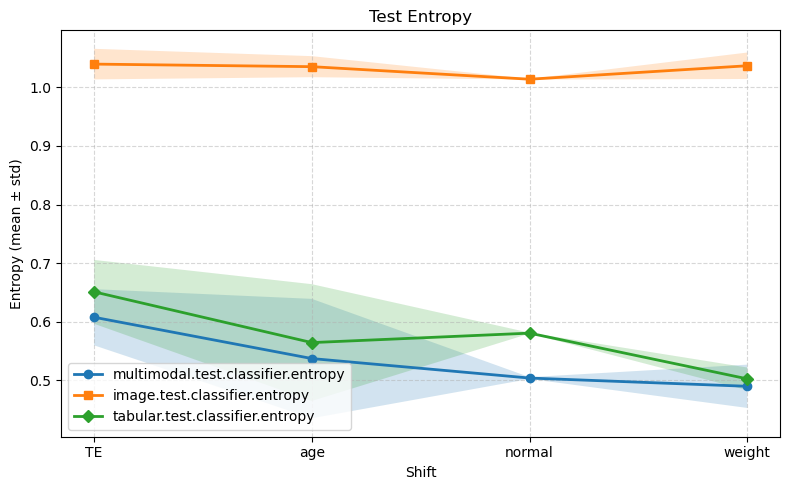

In [14]:
plot_one_grouped_df(summed_df_baseline_test, metrics=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Test Entropy", metric_name="Entropy")

In [15]:
summed_df_baseline_test

multimodal.test.classifier.entropy            \
                                     mean       std   
Shift                                                 
TE                               0.607700  0.047916   
age                              0.537206  0.101856   
normal                           0.503943  0.001517   
weight                           0.489874  0.036939   

       image.test.classifier.entropy            \
                                mean       std   
Shift                                            
TE                          1.039594  0.026097   
age                         1.035215  0.017957   
normal                      1.013813  0.000598   
weight                      1.036768  0.022576   

       tabular.test.classifier.entropy            test.acc            \
                                  mean       std      mean       std   
Shift                                                                  
TE                            0.651024  0.054470  0.830252  0.005315   
age                           0.564431  0.099658  0.812727  0.006356   
normal                        0.580573  0.000739  0.842241  0.004164   
weight                        0.502532  0.019367  0.840833  0.012076   

        test.auc            
            mean       std  
Shift                       
TE      0.936569  0.006186  
age     0.891711  0.008411  
normal  0.935455  0.001200  
weight  0.941193  0.007299

In [16]:
summed_df_baseline_test["test.acc"]

,mean,std
Shift,,
TE,0.830252,0.005315
age,0.812727,0.006356
normal,0.842241,0.004164
weight,0.840833,0.012076


In [17]:
baseline_path = os.path.join(BASE_PATH, "smaller_dataset/baseline")
df_baseline_eval = create_one_group_df(dir_path=baseline_path, filename="eval")
df_baseline_eval =  make_df_numeric(df=df_baseline_eval[["Shift", "multimodal.classifier.entropy", "image.classifier.entropy", "tabular.classifier.entropy", "classifier.multi.acc", "classifier.image.acc", "classifier.tab.acc", "multimodal.train.case1_ratio", "multimodal.train.case2_i_ratio", "multimodal.train.case2_t_ratio", "multimodal.train.case3_ratio"]])
summed_df_baseline_eval = summarize_df(df=df_baseline_eval, group_col="Shift")
summed_df_baseline_eval

multimodal.classifier.entropy           image.classifier.entropy  \
                                mean       std                     mean   
Shift                                                                     
TE                           0.57631  0.020011                  1.02581   
age                          0.52803  0.010485                  1.03490   
normal                       0.55597  0.004103                  1.04093   
weight                       0.55399  0.012868                  1.02716   

                 tabular.classifier.entropy           classifier.multi.acc  \
             std                       mean       std                 mean   
Shift                                                                        
TE      0.005789                    0.58821  0.018710              0.75895   
age     0.015370                    0.53323  0.019364              0.78243   
normal  0.001604                    0.56902  0.002199              0.76618   
weight  0.013888                    0.56079  0.017833              0.76480   

                 classifier.image.acc           classifier.tab.acc            \
             std                 mean       std               mean       std   
Shift                                                                          
TE      0.006508              0.48709  0.000601            0.76121  0.008292   
age     0.025493              0.46055  0.005453            0.77701  0.019963   
normal  0.004263              0.48281  0.003635            0.76711  0.002360   
weight  0.005666              0.48727  0.001170            0.76646  0.006717   

       multimodal.train.case1_ratio           multimodal.train.case2_i_ratio  \
                               mean       std                           mean   
Shift                                                                          
TE                          0.51830  0.012989                        0.02537   
age                         0.50094  0.009990                        0.02317   
normal                      0.49700  0.006235                        0.01850   
weight                      0.52641  0.021601                        0.01947   

                 multimodal.train.case2_t_ratio            \
             std                           mean       std   
Shift                                                       
TE      0.008804                        0.42779  0.004821   
age     0.007838                        0.45944  0.010239   
normal  0.004159                        0.46224  0.005801   
weight  0.007004                        0.43185  0.024652   

       multimodal.train.case3_ratio            
                               mean       std  
Shift                                          
TE                          0.02856  0.004137  
age                         0.01645  0.006353  
normal                      0.02224  0.003888  
weight                      0.02229  0.008437

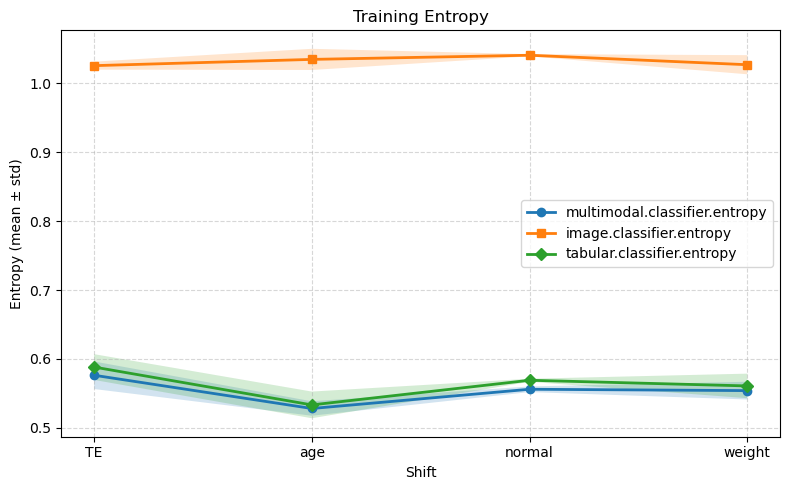

In [18]:
plot_one_grouped_df(summed_df_baseline_eval, metrics=["multimodal.classifier.entropy", "image.classifier.entropy", "tabular.classifier.entropy"], title="Training Entropy", metric_name="Entropy")

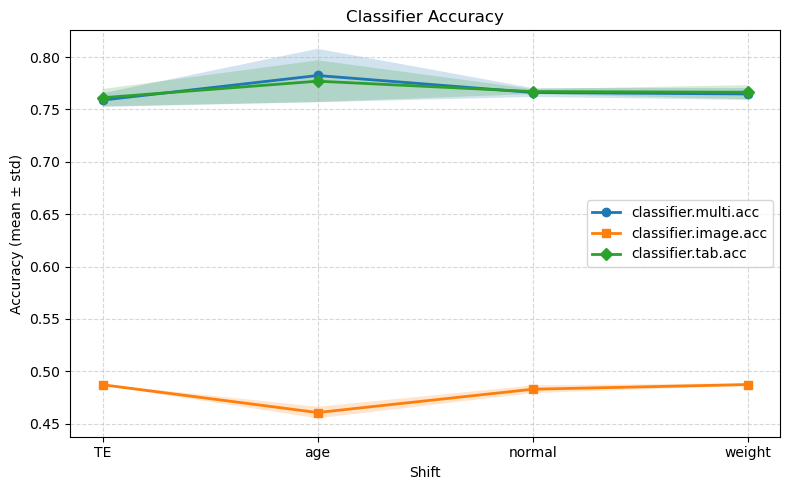

In [19]:
plot_one_grouped_df(summed_df_baseline_eval, metrics=["classifier.multi.acc", "classifier.image.acc", "classifier.tab.acc"], title="Classifier Accuracy", metric_name="Accuracy")

In [20]:
summed_df_baseline_eval[["multimodal.train.case1_ratio", "multimodal.train.case2_i_ratio", "multimodal.train.case2_t_ratio", "multimodal.train.case3_ratio"]]

multimodal.train.case1_ratio           multimodal.train.case2_i_ratio  \
                               mean       std                           mean   
Shift                                                                          
TE                          0.51830  0.012989                        0.02537   
age                         0.50094  0.009990                        0.02317   
normal                      0.49700  0.006235                        0.01850   
weight                      0.52641  0.021601                        0.01947   

                 multimodal.train.case2_t_ratio            \
             std                           mean       std   
Shift                                                       
TE      0.008804                        0.42779  0.004821   
age     0.007838                        0.45944  0.010239   
normal  0.004159                        0.46224  0.005801   
weight  0.007004                        0.43185  0.024652   

       multimodal.train.case3_ratio            
                               mean       std  
Shift                                          
TE                          0.02856  0.004137  
age                         0.01645  0.006353  
normal                      0.02224  0.003888  
weight                      0.02229  0.008437

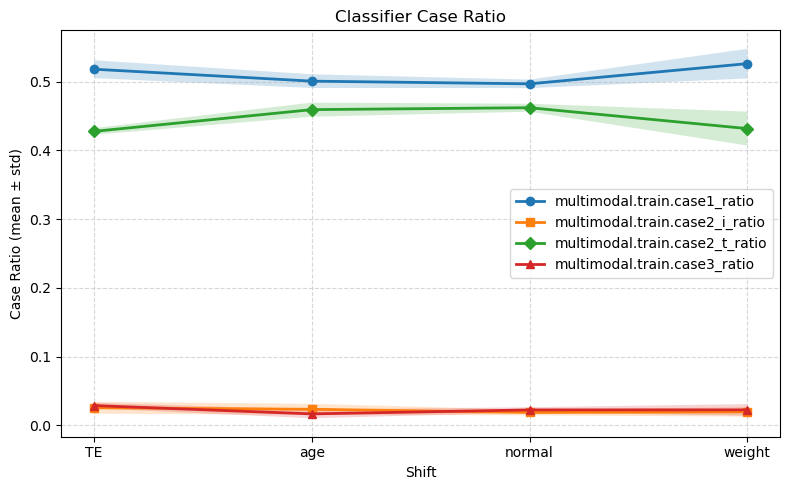

In [21]:
plot_one_grouped_df(summed_df_baseline_eval, metrics=["multimodal.train.case1_ratio", "multimodal.train.case2_i_ratio", "multimodal.train.case2_t_ratio", "multimodal.train.case3_ratio"], title="Classifier Case Ratio", metric_name="Case Ratio")

## Trainable Consent

### Keep all Embedding parts & contribute to classifier loss

#### Loss

$$
\mathcal{L} = \alpha \left(\mathcal{L}_{ce}(y_{m}, y) + \mathcal{L}_{ce}(y_{i}, y) + \mathcal{L}_{ce}(y_{t}, y)\right)+ \beta \left(\mathcal{L}_{CLIP}(feat_{i}, feat_{t})\right) + \gamma \left(\mathcal{L}^{i}_{ds} + \mathcal{L}^{t}_{ds}\right) + \epsilon \left( \mathcal{L}_{ce}(y^{*}, y) \right)
$$

where:

- $\mathcal{L}_{ce} = \text{Cross-Entropy Loss}$
- $\mathcal{L}_{CLIP} = \text{CLIP Loss}$
- $\mathcal{L}_{ds} = \text{CLUB Loss}$
- $\alpha = 0.2$ 
- $\beta = 3.0$ 
- $\gamma = 0.5$ 
- $\epsilon = [0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0]$

In [22]:
consent_path = os.path.join(BASE_PATH, "smaller_dataset/train_consent")
group_col = "epsilon"
df_c = create_two_group_df(dir_path=consent_path, filename="test", group_col=group_col, exp_name="consent")
summed_c_df = summarize_two_groups_df(df=df_c, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
TE,0.830252,0.005315
age,0.812727,0.006356
normal,0.842241,0.004164
weight,0.840833,0.012076


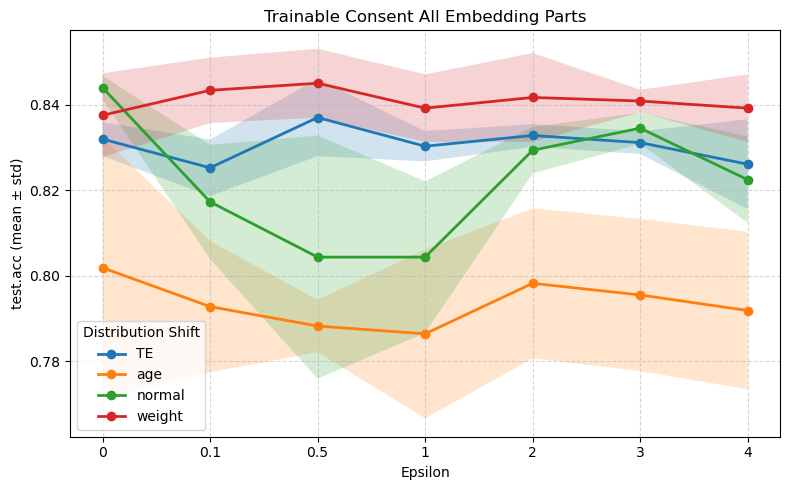

In [23]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Trainable Consent All Embedding Parts")

### Only keep refined Embeddings & contribute to classifier loss

In [24]:
refined_path = os.path.join(BASE_PATH, "smaller_dataset/train_consent_cut")
group_col = "epsilon"
df_c_keep = create_two_group_df(dir_path=refined_path, filename="test", group_col=group_col, exp_name="consent")
summed_c_keep_df = summarize_two_groups_df(df=df_c_keep, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
TE,0.830252,0.005315
age,0.812727,0.006356
normal,0.842241,0.004164
weight,0.840833,0.012076


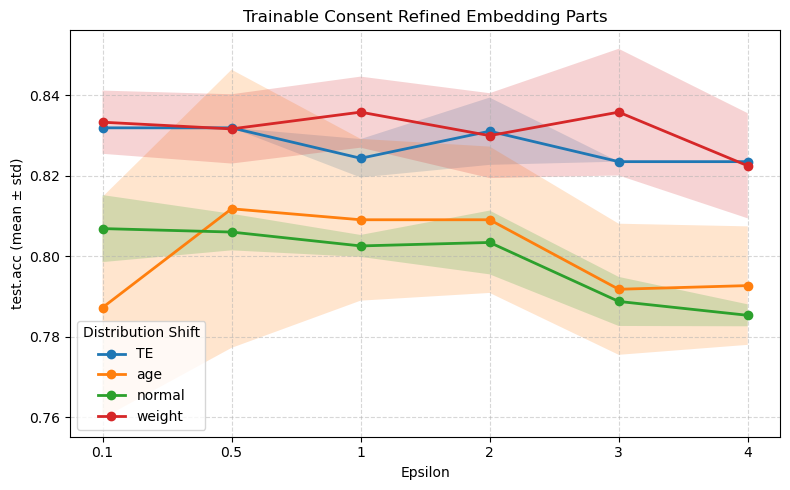

In [25]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_keep_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Trainable Consent Refined Embedding Parts")

### Keep all Embedding parts & Replace CE Classifier Loss

$$
\mathcal{L} = \beta \left(\mathcal{L}_{CLIP}(feat_{i}, feat_{t})\right) + \gamma \left(\mathcal{L}^{i}_{ds} + \mathcal{L}^{t}_{ds}\right) + \epsilon \left( \mathcal{L}_{ce}(y^{*}, y) \right)
$$

where:

- $\mathcal{L}_{ce} = \text{Cross-Entropy Loss}$
- $\mathcal{L}_{CLIP} = \text{CLIP Loss}$
- $\mathcal{L}_{ds} = \text{CLUB Loss}$
- $\beta = 3.0$ 
- $\gamma = 0.5$ 
- $\epsilon = [0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0]$

In [26]:
loss_path = os.path.join(BASE_PATH, "smaller_dataset/train_consent_loss")
group_col = "epsilon"
df_c_loss = create_two_group_df(dir_path=loss_path, filename="test", group_col=group_col, exp_name="consent")
summed_c_loss_df = summarize_two_groups_df(df=df_c_loss, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
TE,0.830252,0.005315
age,0.812727,0.006356
normal,0.842241,0.004164
weight,0.840833,0.012076


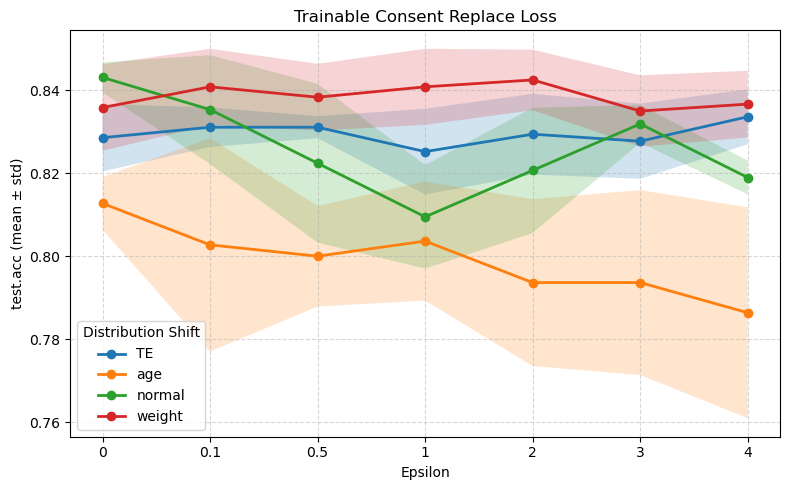

In [27]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_loss_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Trainable Consent Replace Loss")

## Mixture of Experts

#### Loss

$$
\mathcal{L} = \alpha \left(\mathcal{L}_{ce}(y_{m}, y) + \mathcal{L}_{ce}(y_{i}, y) + \mathcal{L}_{ce}(y_{t}, y)\right)+ \beta \left(\mathcal{L}_{CLIP}(feat_{i}, feat_{t})\right) + \gamma \left(\mathcal{L}^{i}_{ds} + \mathcal{L}^{t}_{ds}\right) + \epsilon \left( \mathcal{L}_{MoE}(y^{*}, y) \right)
$$

where:

- $\mathcal{L}_{ce} = \text{Cross-Entropy Loss}$
- $\mathcal{L}_{CLIP} = \text{CLIP Loss}$
- $\mathcal{L}_{ds} = \text{CLUB Loss}$
- $\mathcal{L}_{MoE} = \text{Load Balancing Loss}$
- $\alpha = 0.2$ 
- $\beta = 3.0$ 
- $\gamma = 0.5$ 
- $\epsilon = [0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0]$

#### Classifier Input

- Gate: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Multimodal: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Imaging: $\mathcal{z}^{i}_{c}$
- Tabular: $\mathcal{z}^{t}_{c}$

#### k = 1

In [28]:
moe_path = os.path.join(BASE_PATH, "smaller_dataset/MoE_1_cut")
group_col = "epsilon"
df_c_moe = create_two_group_df(dir_path=moe_path, filename="test", group_col=group_col, exp_name="MoE")
summed_c_moe_df = summarize_two_groups_df(df=df_c_moe, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
TE,0.830252,0.005315
age,0.812727,0.006356
normal,0.842241,0.004164
weight,0.840833,0.012076


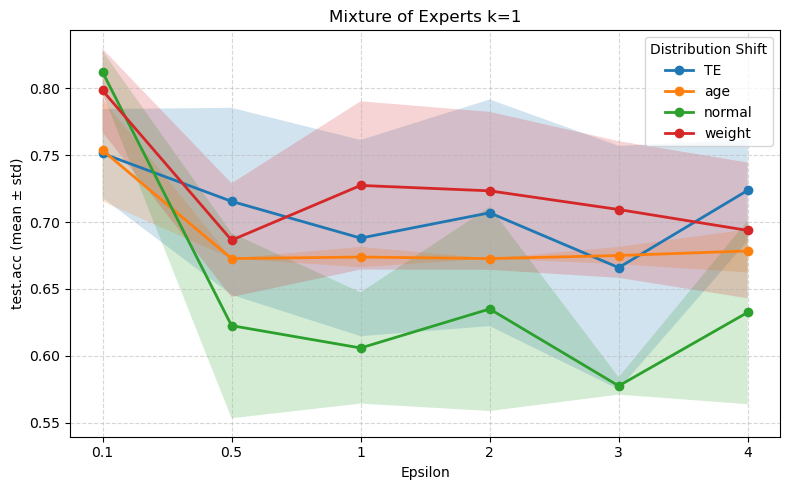

In [29]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_moe_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Mixture of Experts k=1")

#### k = 2

In [30]:
moe_2_path = os.path.join(BASE_PATH, "smaller_dataset/MoE_2_cut")
group_col = "epsilon"
df_c_moe_2 = create_two_group_df(dir_path=moe_2_path, filename="test", group_col=group_col, exp_name="MoE")
summed_c_moe_2_df = summarize_two_groups_df(df=df_c_moe_2, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
TE,0.830252,0.005315
age,0.812727,0.006356
normal,0.842241,0.004164
weight,0.840833,0.012076


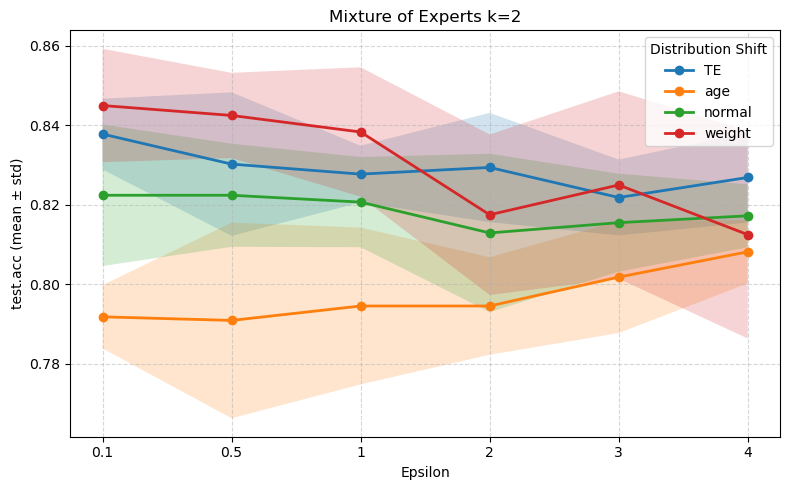

In [31]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_moe_2_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Mixture of Experts k=2")

#### k = 3


In [32]:
moe_3_path = os.path.join(BASE_PATH, "smaller_dataset/MoE_3_cut")
group_col = "epsilon"
df_c_moe_3 = create_two_group_df(dir_path=moe_3_path, filename="test", group_col=group_col, exp_name="MoE")
summed_c_moe_3_df = summarize_two_groups_df(df=df_c_moe_3, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
TE,0.830252,0.005315
age,0.812727,0.006356
normal,0.842241,0.004164
weight,0.840833,0.012076


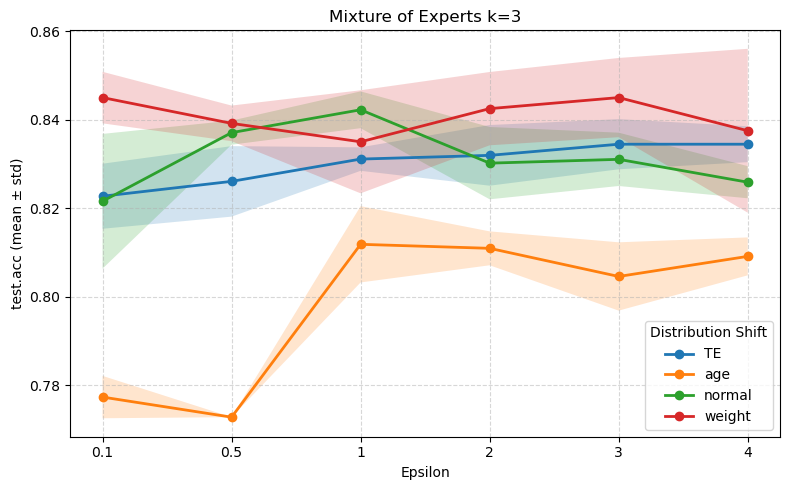

In [33]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_moe_3_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Mixture of Experts k=3")

#### Classifier Input

- Gate: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Multimodal: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Imaging: $\mathcal{z}^{i}_{c} + \mathcal{z}^{i}_{s}$
- Tabular: $\mathcal{z}^{t}_{c} + \mathcal{z}^{t}_{s}$

#### k = 1

## Bigger Dataset (removed GDTOTAL)

### Baseline

In [34]:
nogd_b_path = os.path.join(BASE_PATH, "smaller_dataset/batch_size_no_GDTOTAL")
group_col = "epsilon"
df_c_nogd_b = create_one_group_df(dir_path=nogd_b_path, filename="test", batchsize=True)
summed_c_nogd_b_df = summarize_df(df=df_c_nogd_b, group_col="BatchSize")
summed_c_nogd_b_df

/tmp/ipykernel_3439843/1263068295.py:7: FutureWarning: ['Shift'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  return make_df_numeric(df).groupby(group_col).agg(['mean', 'std'])


multimodal.test.classifier.entropy            \
                                        mean       std   
BatchSize                                                
128                                 0.482298  0.001504   
16                                  0.452684  0.048495   
32                                  0.471573  0.032129   
64                                  0.482664  0.002502   

          image.test.classifier.entropy            \
                                   mean       std   
BatchSize                                           
128                            1.073682  0.000763   
16                             1.066935  0.011164   
32                             1.071096  0.006971   
64                             1.073544  0.001214   

          tabular.test.classifier.entropy            \
                                     mean       std   
BatchSize                                             
128                              0.506944  0.000811   
16                               0.498725  0.013148   
32                               0.504158  0.008895   
64                               0.507599  0.001807   

          multimodal.test.balanced_acc           image.test.balanced_acc  \
                                  mean       std                    mean   
BatchSize                                                                  
128                           0.799886  0.002721                0.333333   
16                            0.791223  0.014285                0.328592   
32                            0.796951  0.008957                0.332966   
64                            0.802067  0.002413                0.333333   

                     ... test.auc_multimodal           test.acc_imaging  \
                std  ...                mean       std             mean   
BatchSize            ...                                                  
128        0.000000  ...            0.916286  0.000472         0.464286   
16         0.009044  ...            0.914081  0.003356         0.436508   
32         0.001163  ...            0.916048  0.001714         0.455159   
64         0.000000  ...            0.916179  0.000744         0.464286   

                    test.auc_imaging           test.acc_tabular            \
                std             mean       std             mean       std   
BatchSize                                                                   
128        0.000000         0.501082  0.019275         0.840476  0.001673   
16         0.046126         0.480325  0.029747         0.837698  0.003475   
32         0.028862         0.490277  0.025371         0.840476  0.002510   
64         0.000000         0.510265  0.026318         0.840476  0.001673   

          test.auc_tabular            
                      mean       std  
BatchSize                             
128               0.916145  0.000134  
16                0.913923  0.003555  
32                0.915605  0.002254  
64                0.916170  0.000254  

[4 rows x 30 columns]

In [35]:
#summed_c_nogd_b_df[["test.acc", "test.balanced_acc"]]

## Final Dataset

### Batchsize

In [36]:
f_batch_path = os.path.join(BASE_PATH, "final_dataset/baseline")
group_col = "epsilon"
df_c_f_batch = create_one_group_df(dir_path=f_batch_path, filename="test", batchsize=True)
#print(df_c_f_b.shape)
df_c_f_batch["BatchSize"] = pd.to_numeric(df_c_f_batch["BatchSize"], errors='coerce')
summed_f_batch_df = summarize_df(df=df_c_f_batch, group_col="BatchSize")
summed_f_batch_df

/tmp/ipykernel_3439843/1263068295.py:7: FutureWarning: ['Shift'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  return make_df_numeric(df).groupby(group_col).agg(['mean', 'std'])


multimodal.test.classifier.entropy            \
                                        mean       std   
BatchSize                                                
32                                  0.397059  0.004863   
64                                  0.493838  0.001887   
128                                 0.376710  0.022668   
256                                 0.442787  0.026465   

          image.test.classifier.entropy            \
                                   mean       std   
BatchSize                                           
32                             1.017297  0.006395   
64                             1.001537  0.003916   
128                            0.993660  0.007150   
256                            1.020991  0.011713   

          tabular.test.classifier.entropy            \
                                     mean       std   
BatchSize                                             
32                               0.448880  0.002890   
64                               0.544314  0.001059   
128                              0.454124  0.008247   
256                              0.488143  0.041894   

          multimodal.test.balanced_acc           image.test.balanced_acc       \
                                  mean       std                    mean  std   
BatchSize                                                                       
32                            0.766958  0.009312                     1.0  0.0   
64                            0.753288  0.005664                     1.0  0.0   
128                           0.740342  0.008365                     1.0  0.0   
256                           0.750139  0.010556                     1.0  0.0   

           ... test.auc_multimodal           test.acc_imaging       \
           ...                mean       std             mean  std   
BatchSize  ...                                                       
32         ...            0.906114  0.003296         0.493333  0.0   
64         ...            0.913928  0.000610         0.493333  0.0   
128        ...            0.906399  0.004323         0.493333  0.0   
256        ...            0.904088  0.004384         0.493333  0.0   

          test.auc_imaging           test.acc_tabular            \
                      mean       std             mean       std   
BatchSize                                                         
32                0.554118  0.012263         0.842400  0.001968   
64                0.591151  0.018622         0.850400  0.000843   
128               0.534143  0.030931         0.843733  0.004391   
256               0.546698  0.021156         0.838400  0.022353   

          test.auc_tabular            
                      mean       std  
BatchSize                             
32                0.906748  0.002829  
64                0.914164  0.000420  
128               0.910598  0.004104  
256               0.904815  0.006009  

[4 rows x 30 columns]

In [37]:
df_c_f_batch[df_c_f_batch["BatchSize"] == 64]

,multimodal.test.classifier.entropy,image.test.classifier.entropy,tabular.test.classifier.entropy,multimodal.test.balanced_acc,image.test.balanced_acc,tabular.test.balanced_acc,test.balanced_acc,test.acc,test.auc,test.acc_multimodal,test.auc_multimodal,test.acc_imaging,test.auc_imaging,test.acc_tabular,test.auc_tabular,Shift,BatchSize
4,0.496994,1.004714,0.545843,0.754650,1.0,0.767706,0.754650,0.837333,0.914836,0.837333,0.914836,0.493333,0.597778,0.850667,0.913253,1_adni_normal_final,64
7,0.492534,1.000245,0.545428,0.753955,1.0,0.767706,0.753955,0.837333,0.914146,0.837333,0.914146,0.493333,0.595912,0.850667,0.914265,1_adni_normal_final,64
12,0.495690,1.009358,0.543342,0.751687,1.0,0.767706,0.751687,0.837333,0.914519,0.837333,0.914519,0.493333,0.582411,0.850667,0.914485,1_adni_normal_final,64
13,0.491297,0.997979,0.542776,0.746740,1.0,0.767706,0.746740,0.832000,0.913677,0.832000,0.913677,0.493333,0.568770,0.850667,0.914155,1_adni_normal_final,64
15,0.491576,0.998664,0.543623,0.749909,1.0,0.767706,0.749909,0.834667,0.913018,0.834667,0.913018,0.493333,0.617722,0.850667,0.914472,1_adni_normal_final,64
17,0.495953,0.999336,0.544415,0.758901,1.0,0.758224,0.758901,0.842667,0.914171,0.842667,0.914171,0.493333,0.601266,0.848000,0.914018,1_adni_normal_final,64
20,0.494170,0.998076,0.543753,0.766228,1.0,0.767706,0.766228,0.845333,0.913395,0.845333,0.913395,0.493333,0.588905,0.850667,0.914691,1_adni_normal_final,64
26,0.493031,1.005590,0.543622,0.749214,1.0,0.767706,0.749214,0.834667,0.914571,0.834667,0.914571,0.493333,0.606400,0.850667,0.914362,1_adni_normal_final,64
27,0.493551,0.998519,0.544703,0.751687,1.0,0.767706,0.751687,0.837333,0.913284,0.837333,0.913284,0.493333,0.554010,0.850667,0.913711,1_adni_normal_final,64
35,0.493583,1.002891,0.545641,0.749909,1.0,0.767706,0.749909,0.834667,0.913665,0.834667,0.913665,0.493333,0.598340,0.850667,0.914227,1_adni_normal_final,64


In [38]:
summed_f_batch_df[["test.acc", "test.balanced_acc"]]

test.acc           test.balanced_acc          
               mean       std              mean       std
BatchSize                                                
32         0.838400  0.002249          0.766958  0.009312
64         0.837333  0.003975          0.753288  0.005664
128        0.839733  0.003864          0.740342  0.008365
256        0.834400  0.014576          0.750139  0.010556

### Baseline

In [39]:
def plot_results(path: str, group_col: str, filename: str, second_group_col: str, exp_name: str, metric: str, title: str):
    moe_path = os.path.join(BASE_PATH, path)
    df_c_moe = create_two_group_df(dir_path=moe_path, filename=filename, group_col=group_col, exp_name=exp_name)
    summed_c_moe_df = summarize_two_groups_df(df=df_c_moe, first_group_col=group_col, second_group_col=second_group_col)
    moe_cols = [c for c in summed_c_moe_df.columns if str(c[0]).startswith('MoE.test.weight') or str(c[0]) in [group_col, second_group_col]]
    if moe_cols:
        moe_cols = [c for c in summed_c_moe_df.columns if str(c[0]).startswith('MoE.test.weight')]
        moe_mean_cols = summed_c_moe_df[moe_cols].xs('mean', axis=1, level=1)

        # Prepare a DataFrame to collect max rows
        max_rows = pd.DataFrame()
        extra_cols = [('Shift', ''), ('epsilon', '')]

        # Iterate over shifts
        for shift, group_df in summed_c_moe_df.groupby(('Shift', '')):
            print(f"\nShift: {shift}")
            for col in moe_mean_cols.columns:
                max_val = group_df[col]['mean'].max()  # max value for this weight in this shift
                rows = group_df[group_df[col]['mean'] == max_val]  # rows reaching the max
                print(f"{col} max value: {max_val}")
                #display(rows)
                # Optionally collect all rows
                max_rows = pd.concat([max_rows, rows])
        display(max_rows[extra_cols + moe_cols])

    plot_two_grouped_df(df=summed_c_moe_df, first_group_col=group_col, second_group_col=second_group_col, metric=metric, title=title)

In [40]:
f_base_path = os.path.join(BASE_PATH, "final_dataset/batchsize")
group_col = "epsilon"
df_c_f_base = create_one_group_df(dir_path=f_base_path, filename="test")
summed_f_base_df = summarize_df(df=df_c_f_base, group_col="Shift")
#summed_f_base_df[["val.balanced_acc", "train.balanced_acc", "eval.train.acc", "eval.val.acc"]]

In [41]:
summed_f_base_df[["test.acc", "test.balanced_acc"]]  

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.854933  0.004391          0.818236  0.010816
age     0.833067  0.001865          0.829321  0.002959
normal  0.837600  0.001514          0.752576  0.004230
weight  0.858133  0.003511          0.852770  0.004061


Shift: TE
MoE.test.weight0 max value: 0.408266669511795
MoE.test.weight1 max value: 0.020533334091305706
MoE.test.weight2 max value: 0.5903999924659729

Shift: age
MoE.test.weight0 max value: 0.855733323097229
MoE.test.weight1 max value: 0.13653333336114878
MoE.test.weight2 max value: 0.12746666474267837

Shift: normal
MoE.test.weight0 max value: 0.3240000009536743
MoE.test.weight1 max value: 0.11706666816025968
MoE.test.weight2 max value: 0.5893333256244659

Shift: weight
MoE.test.weight0 max value: 0.9986666738986969
MoE.test.weight1 max value: 0.02346666678786277
MoE.test.weight2 max value: 0.0015999999828636598


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.408267  0.005822         0.008533  0.004131   
16      TE       3         0.400533  0.017545         0.020533  0.036930   
4       TE     0.5         0.402933  0.007161         0.006667  0.002880   
5      age     0.5         0.855733  0.037003         0.104800  0.038047   
13     age       2         0.809067  0.057828         0.136533  0.049679   
17     age       3         0.738933  0.230993         0.133600  0.104696   
6   normal     0.5         0.324000  0.002266         0.111467  0.015791   
22  normal       4         0.320533  0.005152         0.117067  0.037972   
10  normal       1         0.322133  0.005594         0.088533  0.020184   
7   weight     0.5         0.998667  0.001886         0.000000  0.000000   
11  weight       1         0.975200  0.060927         0.023467  0.061453   
15  weight       2         0.984800  0.027913         0.013600  0.028678   

   MoE.test.weight2            
               mean       std  
0          0.583200  0.007955  
16         0.578933  0.022327  
4          0.590400  0.007458  
5          0.039467  0.058637  
13         0.054400  0.063792  
17         0.127467  0.156595  
6          0.564533  0.015296  
22         0.562400  0.040568  
10         0.589333  0.021918  
7          0.001333  0.001886  
11         0.001333  0.002266  
15         0.001600  0.002249

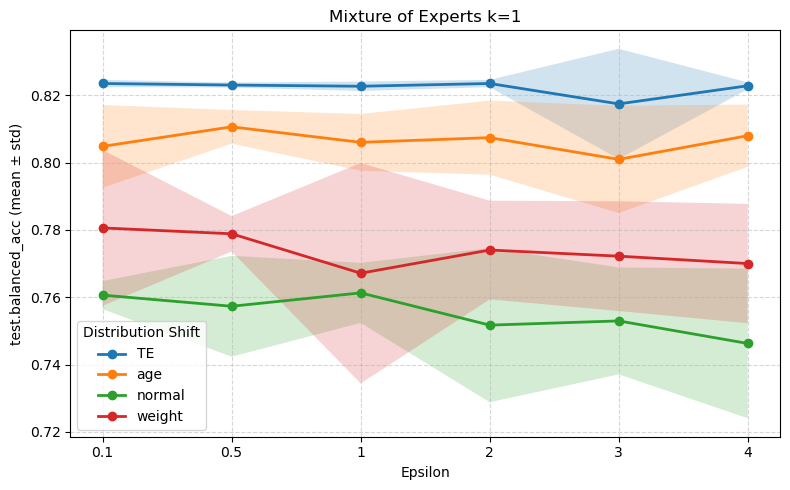

In [42]:
plot_results(path="final_dataset/MoE1", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric="test.balanced_acc", title="Mixture of Experts k=1")


Shift: TE
MoE.test.weight0 max value: 0.41040000319480896
MoE.test.weight1 max value: 0.02053333306685087
MoE.test.weight2 max value: 0.5864000082015991

Shift: age
MoE.test.weight0 max value: 0.7968000054359436
MoE.test.weight1 max value: 0.15013333410024637
MoE.test.weight2 max value: 0.14746666625142094

Shift: normal
MoE.test.weight0 max value: 0.32346666753292086
MoE.test.weight1 max value: 0.11759999915957446
MoE.test.weight2 max value: 0.593066668510437

Shift: weight
MoE.test.weight0 max value: 0.9930666744709015
MoE.test.weight1 max value: 0.04853333234786986
MoE.test.weight2 max value: 0.00133333329576998


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
12      TE       2         0.410400  0.010013         0.012533  0.007117   
0       TE     0.1         0.401600  0.027084         0.020533  0.034725   
20      TE       4         0.405867  0.006260         0.007733  0.002935   
17     age       3         0.796800  0.072058         0.100533  0.026129   
21     age       4         0.762400  0.159175         0.150133  0.048882   
1      age     0.1         0.714933  0.161951         0.137600  0.081847   
2   normal     0.1         0.323467  0.003092         0.117600  0.027353   
2   normal     0.1         0.323467  0.003092         0.117600  0.027353   
10  normal       1         0.316800  0.012683         0.090133  0.040730   
19  weight       3         0.993067  0.018269         0.005867  0.018552   
3   weight     0.1         0.950667  0.078043         0.048533  0.078573   
11  weight       1         0.980000  0.058576         0.018667  0.059029   

   MoE.test.weight2            
               mean       std  
12         0.577067  0.012832  
0          0.577867  0.011593  
20         0.586400  0.008568  
17         0.102667  0.084964  
21         0.087467  0.140460  
1          0.147467  0.124019  
2          0.558933  0.026673  
2          0.558933  0.026673  
10         0.593067  0.048003  
19         0.001067  0.001865  
3          0.000800  0.001800  
11         0.001333  0.001405

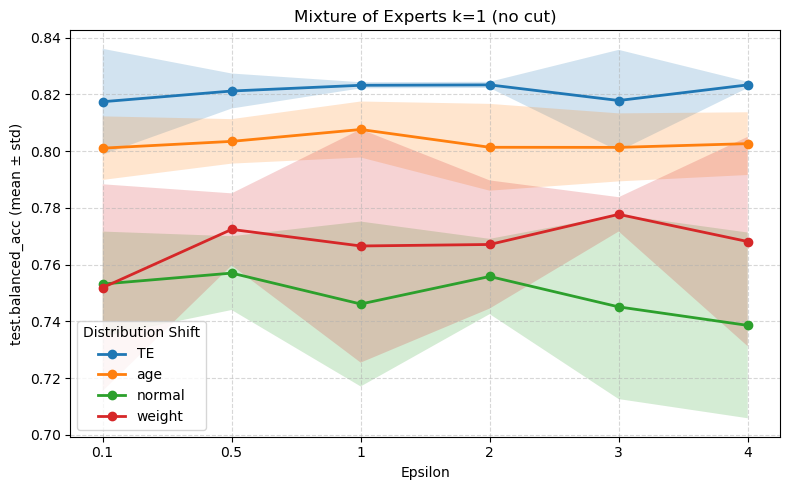

In [43]:
plot_results(path="final_dataset/MoE1-no-cut", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric="test.balanced_acc", title="Mixture of Experts k=1 (no cut)")


Shift: TE
MoE.test.weight0 max value: 0.36384894847869875
MoE.test.weight1 max value: 0.37157583236694336
MoE.test.weight2 max value: 0.43263658583164216

Shift: age
MoE.test.weight0 max value: 0.4007679998874664
MoE.test.weight1 max value: 0.41185267865657804
MoE.test.weight2 max value: 0.36621026992797845

Shift: normal
MoE.test.weight0 max value: 0.37120809853076936
MoE.test.weight1 max value: 0.3429577648639679
MoE.test.weight2 max value: 0.3822664827108383

Shift: weight
MoE.test.weight0 max value: 0.3628387600183487
MoE.test.weight1 max value: 0.3612213104963302
MoE.test.weight2 max value: 0.4358952581882477


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
20      TE       4         0.363849  0.099983         0.371576  0.089902   
20      TE       4         0.363849  0.099983         0.371576  0.089902   
16      TE       3         0.266679  0.155568         0.300684  0.145997   
21     age       4         0.400768  0.098327         0.368414  0.108198   
1      age     0.1         0.306217  0.076421         0.411853  0.047877   
5      age     0.5         0.238488  0.126144         0.395302  0.045248   
18  normal       3         0.371208  0.081745         0.303169  0.188771   
2   normal     0.1         0.292833  0.013344         0.342958  0.018406   
14  normal       2         0.361714  0.073726         0.256020  0.147313   
15  weight       2         0.362839  0.086994         0.275193  0.147004   
7   weight     0.5         0.333124  0.028657         0.361221  0.030881   
19  weight       3         0.299710  0.123744         0.264395  0.153973   

   MoE.test.weight2            
               mean       std  
20         0.264575  0.186265  
20         0.264575  0.186265  
16         0.432637  0.065134  
21         0.230818  0.154386  
1          0.281930  0.087226  
5          0.366210  0.111103  
18         0.325623  0.164323  
2          0.364209  0.015928  
14         0.382266  0.079588  
15         0.361968  0.068168  
7          0.305655  0.011694  
19         0.435895  0.088436

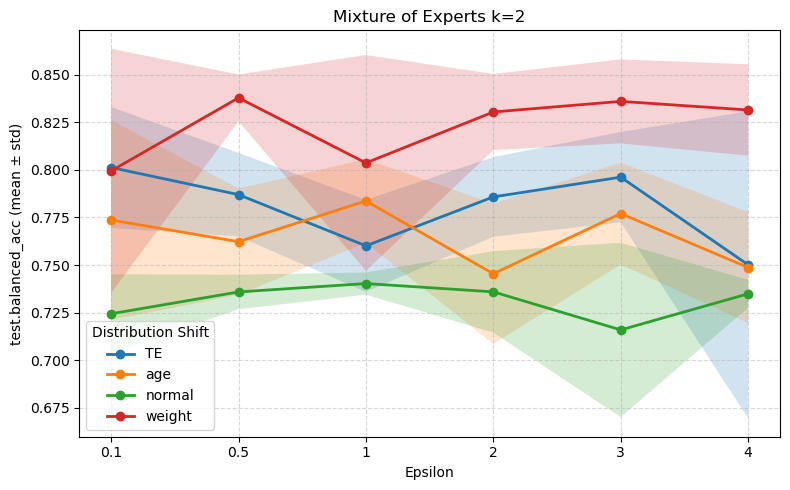

In [44]:
plot_results(path="final_dataset/MoE2", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric="test.balanced_acc", title="Mixture of Experts k=2")


Shift: TE
MoE.test.weight0 max value: 0.3780180300985064
MoE.test.weight1 max value: 0.34877635751451763
MoE.test.weight2 max value: 0.39238818628447397

Shift: age
MoE.test.weight0 max value: 0.4036405661276409
MoE.test.weight1 max value: 0.41406541211264475
MoE.test.weight2 max value: 0.3839018451316016

Shift: normal
MoE.test.weight0 max value: 0.3837187205042158
MoE.test.weight1 max value: 0.37064009053366526
MoE.test.weight2 max value: 0.3438799849578312

Shift: weight
MoE.test.weight0 max value: 0.37226580721991404
MoE.test.weight1 max value: 0.36849227121898104
MoE.test.weight2 max value: 0.39100340860230576


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
4       TE     0.5         0.378018  0.044913         0.332395  0.049873   
0       TE     0.1         0.356474  0.060415         0.348776  0.045878   
20      TE       4         0.330291  0.045157         0.277321  0.028794   
13     age       2         0.403641  0.080603         0.301872  0.117401   
5      age     0.5         0.339781  0.099854         0.414065  0.062008   
21     age       4         0.379848  0.111124         0.236250  0.101218   
14  normal       2         0.383719  0.023205         0.319359  0.062490   
2   normal     0.1         0.323468  0.034415         0.370640  0.024172   
22  normal       4         0.353969  0.014080         0.302151  0.022295   
7   weight     0.5         0.372266  0.049514         0.348628  0.056210   
19  weight       3         0.290800  0.097416         0.368492  0.061809   
3   weight     0.1         0.301261  0.026342         0.307735  0.046692   

   MoE.test.weight2            
               mean       std  
4          0.289587  0.046906  
0          0.294749  0.030915  
20         0.392388  0.049449  
13         0.294488  0.126495  
5          0.246154  0.120014  
21         0.383902  0.073763  
14         0.296922  0.057974  
2          0.305892  0.036030  
22         0.343880  0.031795  
7          0.279106  0.083777  
19         0.340708  0.059365  
3          0.391003  0.053502

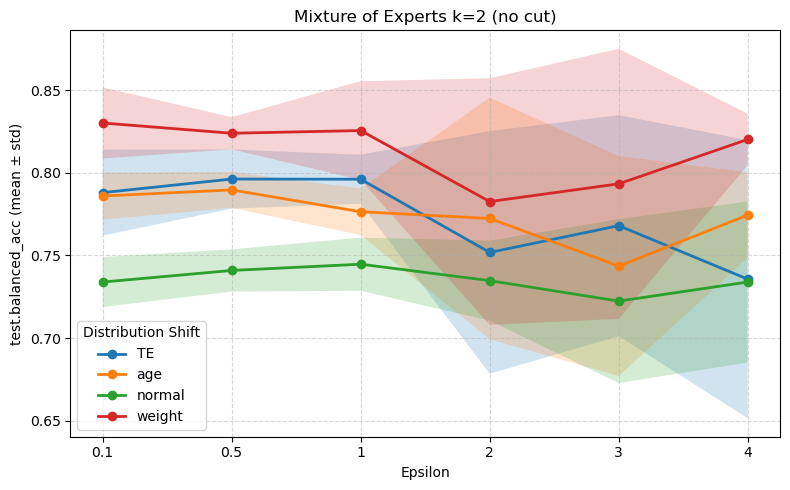

In [45]:
plot_results(path="final_dataset/MoE2-no-cut", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric="test.balanced_acc", title="Mixture of Experts k=2 (no cut)")


Shift: TE
MoE.test.weight0 max value: 0.38854463398456573
MoE.test.weight1 max value: 0.3292195449272792
MoE.test.weight2 max value: 0.3404563750539507

Shift: age
MoE.test.weight0 max value: 0.3924391319354375
MoE.test.weight1 max value: 0.3551468700170517
MoE.test.weight2 max value: 0.3447087953488032

Shift: normal
MoE.test.weight0 max value: 0.41325434545675915
MoE.test.weight1 max value: 0.32146139939626056
MoE.test.weight2 max value: 0.34778800180980135

Shift: weight
MoE.test.weight0 max value: 0.36564358075459796
MoE.test.weight1 max value: 0.36886532107988995
MoE.test.weight2 max value: 0.3447837730248769


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
8       TE       1         0.388545  0.005799         0.296728  0.010156   
20      TE       4         0.343163  0.004090         0.329220  0.001466   
0       TE     0.1         0.344000  0.018375         0.315543  0.023124   
9      age       1         0.392439  0.027958         0.341401  0.044344   
13     age       2         0.368596  0.035452         0.355147  0.015958   
21     age       4         0.327590  0.055736         0.327701  0.037908   
18  normal       3         0.413254  0.042403         0.255220  0.049814   
22  normal       4         0.349205  0.013600         0.321461  0.018707   
2   normal     0.1         0.346206  0.007081         0.306006  0.025276   
11  weight       1         0.365644  0.004437         0.368865  0.004402   
11  weight       1         0.365644  0.004437         0.368865  0.004402   
19  weight       3         0.342533  0.017184         0.312683  0.021681   

   MoE.test.weight2            
               mean       std  
8          0.314727  0.005861  
20         0.327618  0.003217  
0          0.340456  0.014598  
9          0.266160  0.071499  
13         0.276257  0.035314  
21         0.344709  0.025020  
18         0.331526  0.014758  
22         0.329334  0.025618  
2          0.347788  0.021059  
11         0.265491  0.004229  
11         0.265491  0.004229  
19         0.344784  0.025511

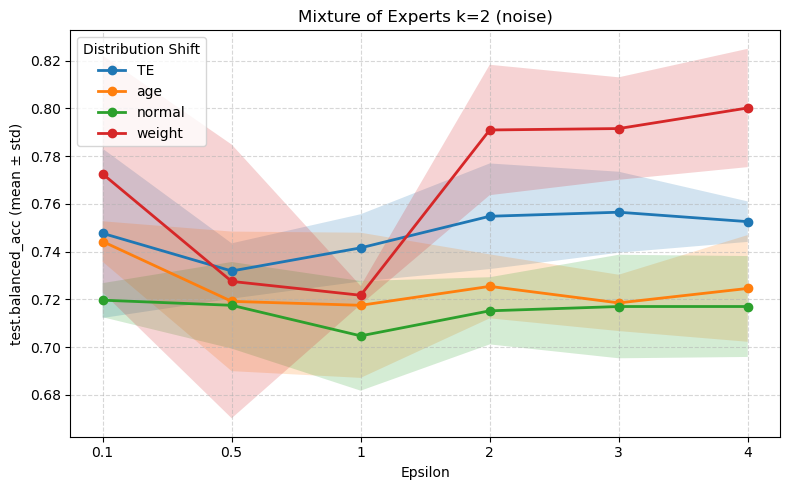

In [46]:
plot_results(path="final_dataset/MoE2-noise", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric="test.balanced_acc", title="Mixture of Experts k=2 (noise)")

In [48]:
plot_results(path="final_dataset/MoE2-MLP-noise", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric="test.balanced_acc", title="Mixture of Experts k=2 (MLP, noise)")

KeyError: 'epsilon'


Shift: TE
MoE.test.weight0 max value: 0.3350094109773636
MoE.test.weight1 max value: 0.3354301244020462
MoE.test.weight2 max value: 0.3432265162467957

Shift: age
MoE.test.weight0 max value: 0.340798395872116
MoE.test.weight1 max value: 0.3500566840171814
MoE.test.weight2 max value: 0.34240913093090053

Shift: normal
MoE.test.weight0 max value: 0.33734545707702634
MoE.test.weight1 max value: 0.345614355802536
MoE.test.weight2 max value: 0.32707934379577636

Shift: weight
MoE.test.weight0 max value: 0.34312105774879453
MoE.test.weight1 max value: 0.33385967612266537
MoE.test.weight2 max value: 0.36610770225524897


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
16      TE       3         0.335009  0.005712         0.333593  0.004261   
20      TE       4         0.331741  0.004981         0.335430  0.003494   
0       TE     0.1         0.323037  0.006991         0.333737  0.003769   
13     age       2         0.340798  0.011166         0.333455  0.020388   
1      age     0.1         0.326710  0.001387         0.350057  0.001549   
9      age       1         0.338608  0.003410         0.318983  0.002994   
6   normal     0.5         0.337345  0.020198         0.339134  0.016322   
18  normal       3         0.331792  0.012304         0.345614  0.010287   
22  normal       4         0.330316  0.004472         0.342605  0.004736   
19  weight       3         0.343121  0.010043         0.329221  0.007892   
23  weight       4         0.334353  0.010942         0.333860  0.009149   
3   weight     0.1         0.305408  0.014695         0.328485  0.012159   

   MoE.test.weight2            
               mean       std  
16         0.331397  0.006506  
20         0.332828  0.005890  
0          0.343227  0.009418  
13         0.325747  0.021271  
1          0.323234  0.001102  
9          0.342409  0.002472  
6          0.323520  0.009203  
18         0.322593  0.012643  
22         0.327079  0.007964  
19         0.327658  0.009286  
23         0.331788  0.014408  
3          0.366108  0.024003

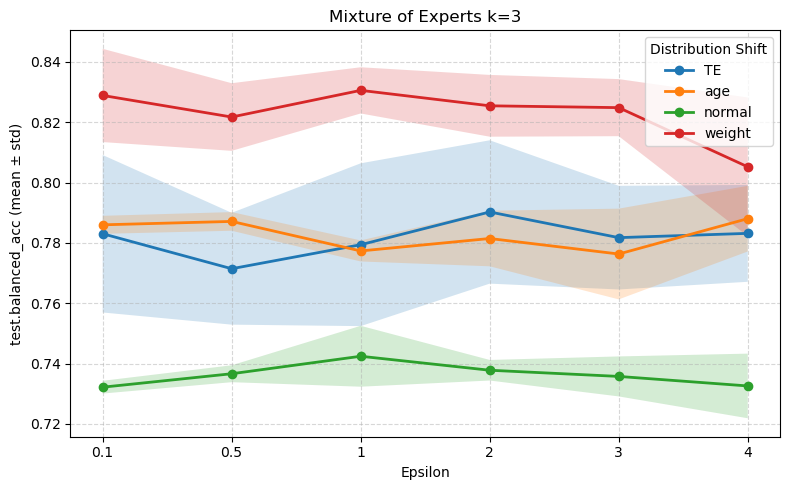

In [47]:
plot_results(path="final_dataset/MoE3", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric="test.balanced_acc", title="Mixture of Experts k=3")